# European Banking Performance Analysis
### Capital, Profitability and Asset Quality, 2019-2023

**Research question:** How did capitalisation, profitability and asset quality evolve across a sample of European banks between 2019 and 2023?

Data: 436 banks across **19** EU/EEA countries (BankFocus export). See `../data/README.md` for the full data dictionary (units, coverage, outliers, balanced-panel check) and `../README.md` for the project overview and limitations.

This notebook runs the full pipeline end-to-end: clean & aggregate raw bank-level data -> generate charts -> summarize findings. The actual logic lives in `../src/` (`aggregation.py`, `data_cleaning.py`, `visualization.py`), imported here rather than duplicated.

**Note on paths:** the `src/` scripts themselves resolve paths relative to their own file location (via `pathlib`), so `python src/data_cleaning.py` works correctly from anywhere. *This notebook* is less robust than that: it uses `sys.path.append('../src')` and relative paths like `../data/data.xlsx`, which only resolve correctly if the notebook is run from its own directory (`notebooks/`) -- which is what happens by default when you open it in Jupyter, but is worth knowing if you copy cells elsewhere.

In [1]:
import sys
sys.path.append('../src')

from data_cleaning import ExcelTool
from visualization import plot_all_sheets
from aggregation import AGGREGATION_RULES, AGGREGATION_DESCRIPTIONS

import pandas as pd
from IPython.display import Image, display
pd.set_option('display.max_columns', None)

## 1. Aggregation methodology

Absolute monetary variables (Tier 1 Capital, NII, Impaired loans -- reported in the raw data in **EUR**, not thousands) are **summed** across banks in a country-year. Ratio variables (Tier 1 Ratio, ROAA, ROAE, etc.) are aggregated as a **median**, describing the *representative bank* in the sample, since no reliable weights were available for a weighted average. Note: "Impaired loans-RWAs" is impaired loans over risk-weighted assets, not the standard NPL ratio (non-performing loans over gross loans) -- similar in spirit, not numerically interchangeable. Full rationale in `src/aggregation.py`.

In [2]:
for indicator, rule in AGGREGATION_RULES.items():
    print(f"{indicator:30s} -> {rule:6s} | {AGGREGATION_DESCRIPTIONS[rule]}")

Tier 1 Capital                 -> sum    | Summed across all reporting banks in the country-year. Represents the aggregate value for the national banking system.
NII                            -> sum    | Summed across all reporting banks in the country-year. Represents the aggregate value for the national banking system.
Impaired loans                 -> sum    | Summed across all reporting banks in the country-year. Represents the aggregate value for the national banking system.
Tier 1 Ratio                   -> median | Median across all reporting banks in the country-year. Represents the typical/representative bank, NOT the national system total, since no reliable weights (RWA, total assets) were available to compute a weighted average or to recompute the ratio from aggregated numerator/denominator.
Tot. cap. adequacy ratio       -> median | Median across all reporting banks in the country-year. Represents the typical/representative bank, NOT the national system total, since no rel

## 2. Clean and aggregate the raw data

- Missing values (`n.a.`) are kept as `NaN` by default (11-38% missing depending on indicator), not imputed.
- Outliers are detected with the IQR method **separately per country and year** (not globally -- comparing a bank only to its national peers) and never removed automatically. Every flagged value is written to `outlier_report.csv` with the **bank name**, country, year and the IQR bounds that triggered the flag.
- Bank coverage per country/year/indicator is written to `coverage_report.csv` -- ranges from 2 banks (Estonia) to 106 (France) *reporting in a single year*.
- A **balanced-panel check** compares full-sample totals against a fixed subset of banks present in all 5 years, for every summed indicator (`balanced_panel_report.csv`). The full-sample bank count here is the number of banks reporting THAT SPECIFIC YEAR, not a static total.

In [3]:
tool = ExcelTool(input_file='../data/data.xlsx', output_file='../data/output_clean.xlsx')
tool.process(impute_missing=False)

167 candidate outliers flagged in 'Tier 1 Capital' (per country/year)
105 candidate outliers flagged in 'Tier 1 Ratio' (per country/year)
136 candidate outliers flagged in 'Tot. cap. adequacy ratio' (per country/year)


233 candidate outliers flagged in 'ROAA' (per country/year)
225 candidate outliers flagged in 'ROAE' (per country/year)
249 candidate outliers flagged in 'NII' (per country/year)


119 candidate outliers flagged in 'NII-RWAs' (per country/year)
187 candidate outliers flagged in 'Impaired loans' (per country/year)
85 candidate outliers flagged in 'Impaired loans-RWAs' (per country/year)
Outlier report written to C:\Users\AgroroticadiBrignani\OneDrive\Documenti\european-banking-performance-analysis\european-banking-performance-analysis\data\outlier_report.csv (1506 flagged values, with bank/country/year and IQR bounds).


Coverage report written to C:\Users\AgroroticadiBrignani\OneDrive\Documenti\european-banking-performance-analysis\european-banking-performance-analysis\data\coverage_report.csv (855 rows).
Balanced panel report written to C:\Users\AgroroticadiBrignani\OneDrive\Documenti\european-banking-performance-analysis\european-banking-performance-analysis\data\balanced_panel_report.csv (285 rows).
EXCEL DATA HAS BEEN PROCESSED
Excel file '../data/output_clean.xlsx' generated successfully!
Processing completed!


In [4]:
# Sanity check: how many countries are actually in the cleaned data?
xl_check = pd.ExcelFile('../data/output_clean.xlsx')
df_check = xl_check.parse('Tier 1 Ratio')
print(f"Countries in cleaned data: {df_check['Country ISO code'].nunique()}")
print(sorted(df_check['Country ISO code'].unique().tolist()))

cov = pd.read_csv('../data/coverage_report.csv')
print("\nMax banks reporting in a single year, per country (any indicator):")
print(cov.groupby('country')['n_banks_reporting'].max().sort_values(ascending=False))

Countries in cleaned data: 19
['AT', 'BE', 'CY', 'DE', 'EE', 'ES', 'FI', 'FR', 'GR', 'IE', 'IT', 'LT', 'LU', 'LV', 'MT', 'NL', 'PT', 'SI', 'SK']

Max banks reporting in a single year, per country (any indicator):
country
FR    106
DE     61
IT     48
ES     46
AT     26
FI     17
PT     17
BE     16
NL     10
IE     10
LU      9
LV      9
CY      8
GR      7
SI      6
MT      6
SK      5
LT      4
EE      3
Name: n_banks_reporting, dtype: int64


## 3. Balanced-panel check

For each summed indicator, compare the full-sample country total against a total computed only from banks present in **all 5 years**. `n_banks_reporting_full_sample` is the number of banks with a non-missing value in that specific year (it varies year to year); `n_banks_balanced_panel` is the fixed subset size (constant across years by construction). This isolates how much of a change in a total reflects genuine growth vs. a changing set of reporting banks -- a partial check, not a full fix (see `../data/README.md`).

In [5]:
bp = pd.read_csv('../data/balanced_panel_report.csv')
example = bp[(bp['sheet'] == 'Tier 1 Capital') & (bp['country'] == 'FR')].sort_values('year')
display(example[['year', 'full_sample_total', 'balanced_panel_total', 'n_banks_reporting_full_sample', 'n_banks_balanced_panel']])

,year,full_sample_total,balanced_panel_total,n_banks_reporting_full_sample,n_banks_balanced_panel
39,2019,4.069413e+11,3.714640e+11,88,77
38,2020,4.368429e+11,4.023396e+11,86,77
37,2021,4.427149e+11,4.173202e+11,86,77
36,2022,4.553651e+11,4.258561e+11,85,77
35,2023,4.553992e+11,4.498021e+11,87,77


## 4. Generate charts

One bar chart per indicator, saved to `../outputs/figures/`. Monetary indicators are shown in EUR billions.

In [6]:
plot_all_sheets('../data/output_clean.xlsx', output_dir='../outputs/figures')

Chart saved as ..\outputs\figures\tier_1_capital.png


Chart saved as ..\outputs\figures\tier_1_ratio.png


Chart saved as ..\outputs\figures\tot_cap_adequacy_ratio.png


Chart saved as ..\outputs\figures\roaa.png


Chart saved as ..\outputs\figures\roae.png


Chart saved as ..\outputs\figures\nii.png


Chart saved as ..\outputs\figures\nii_rwas.png


Chart saved as ..\outputs\figures\impaired_loans.png


Chart saved as ..\outputs\figures\impaired_loans_rwas.png


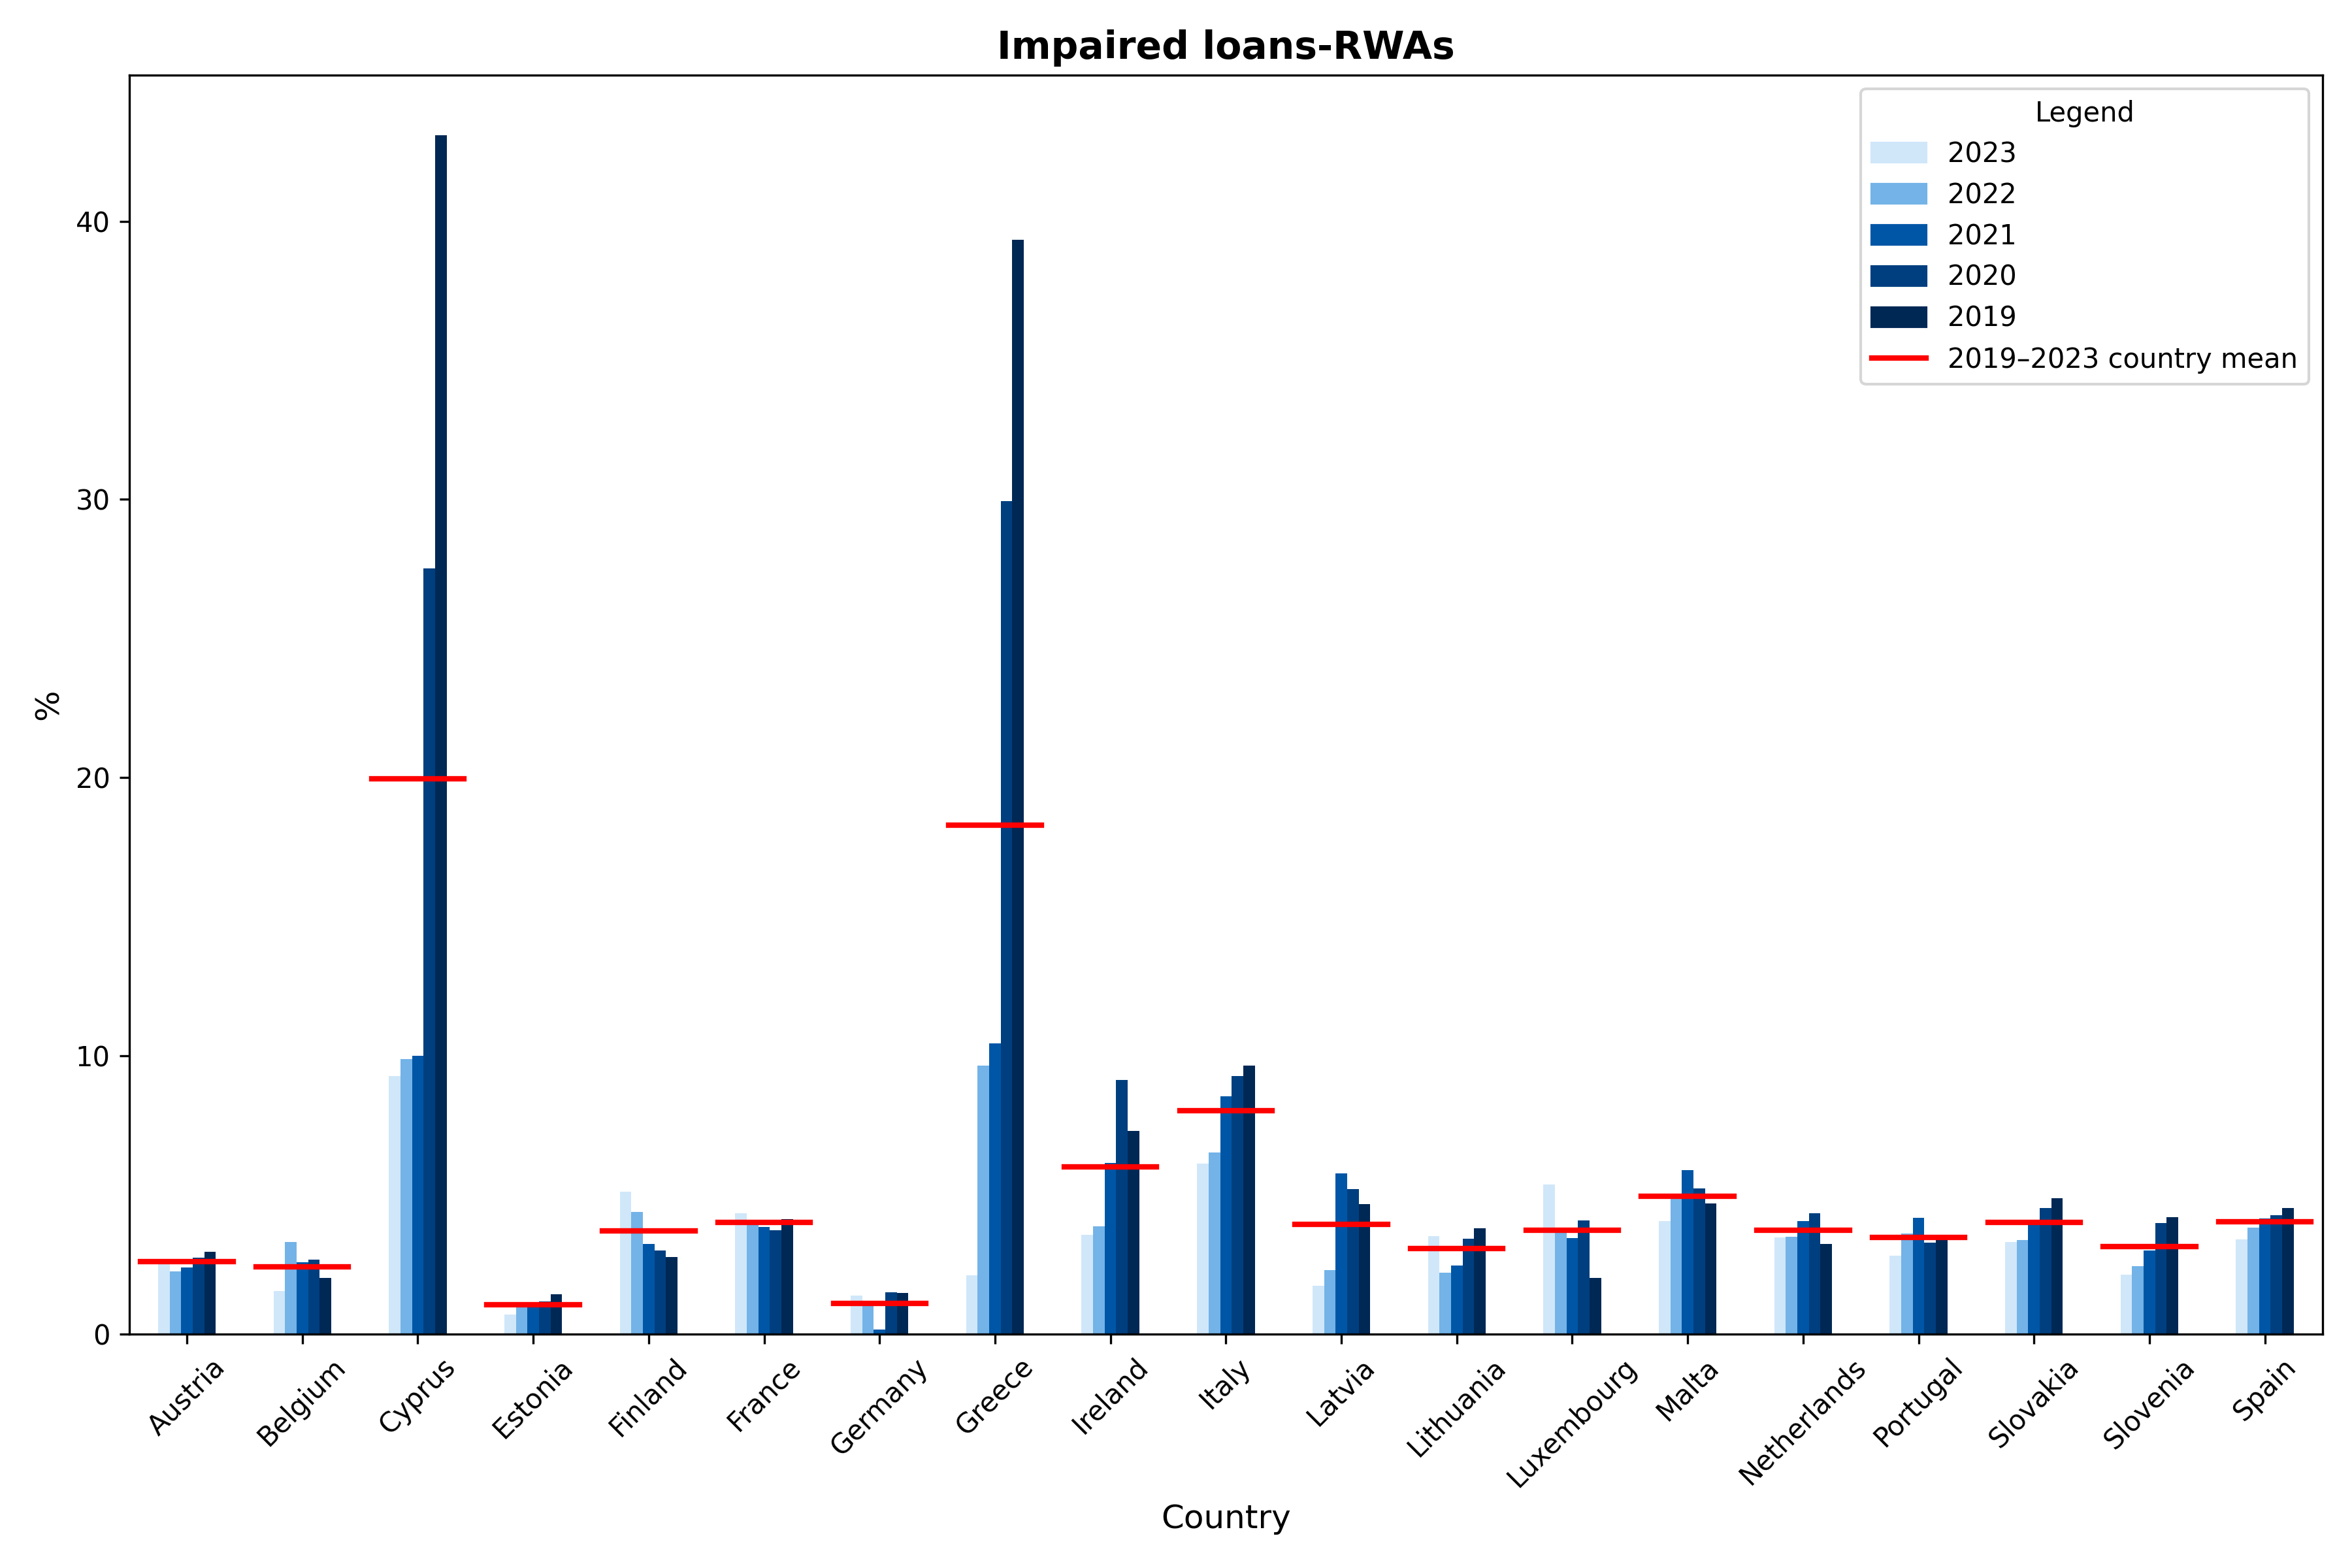

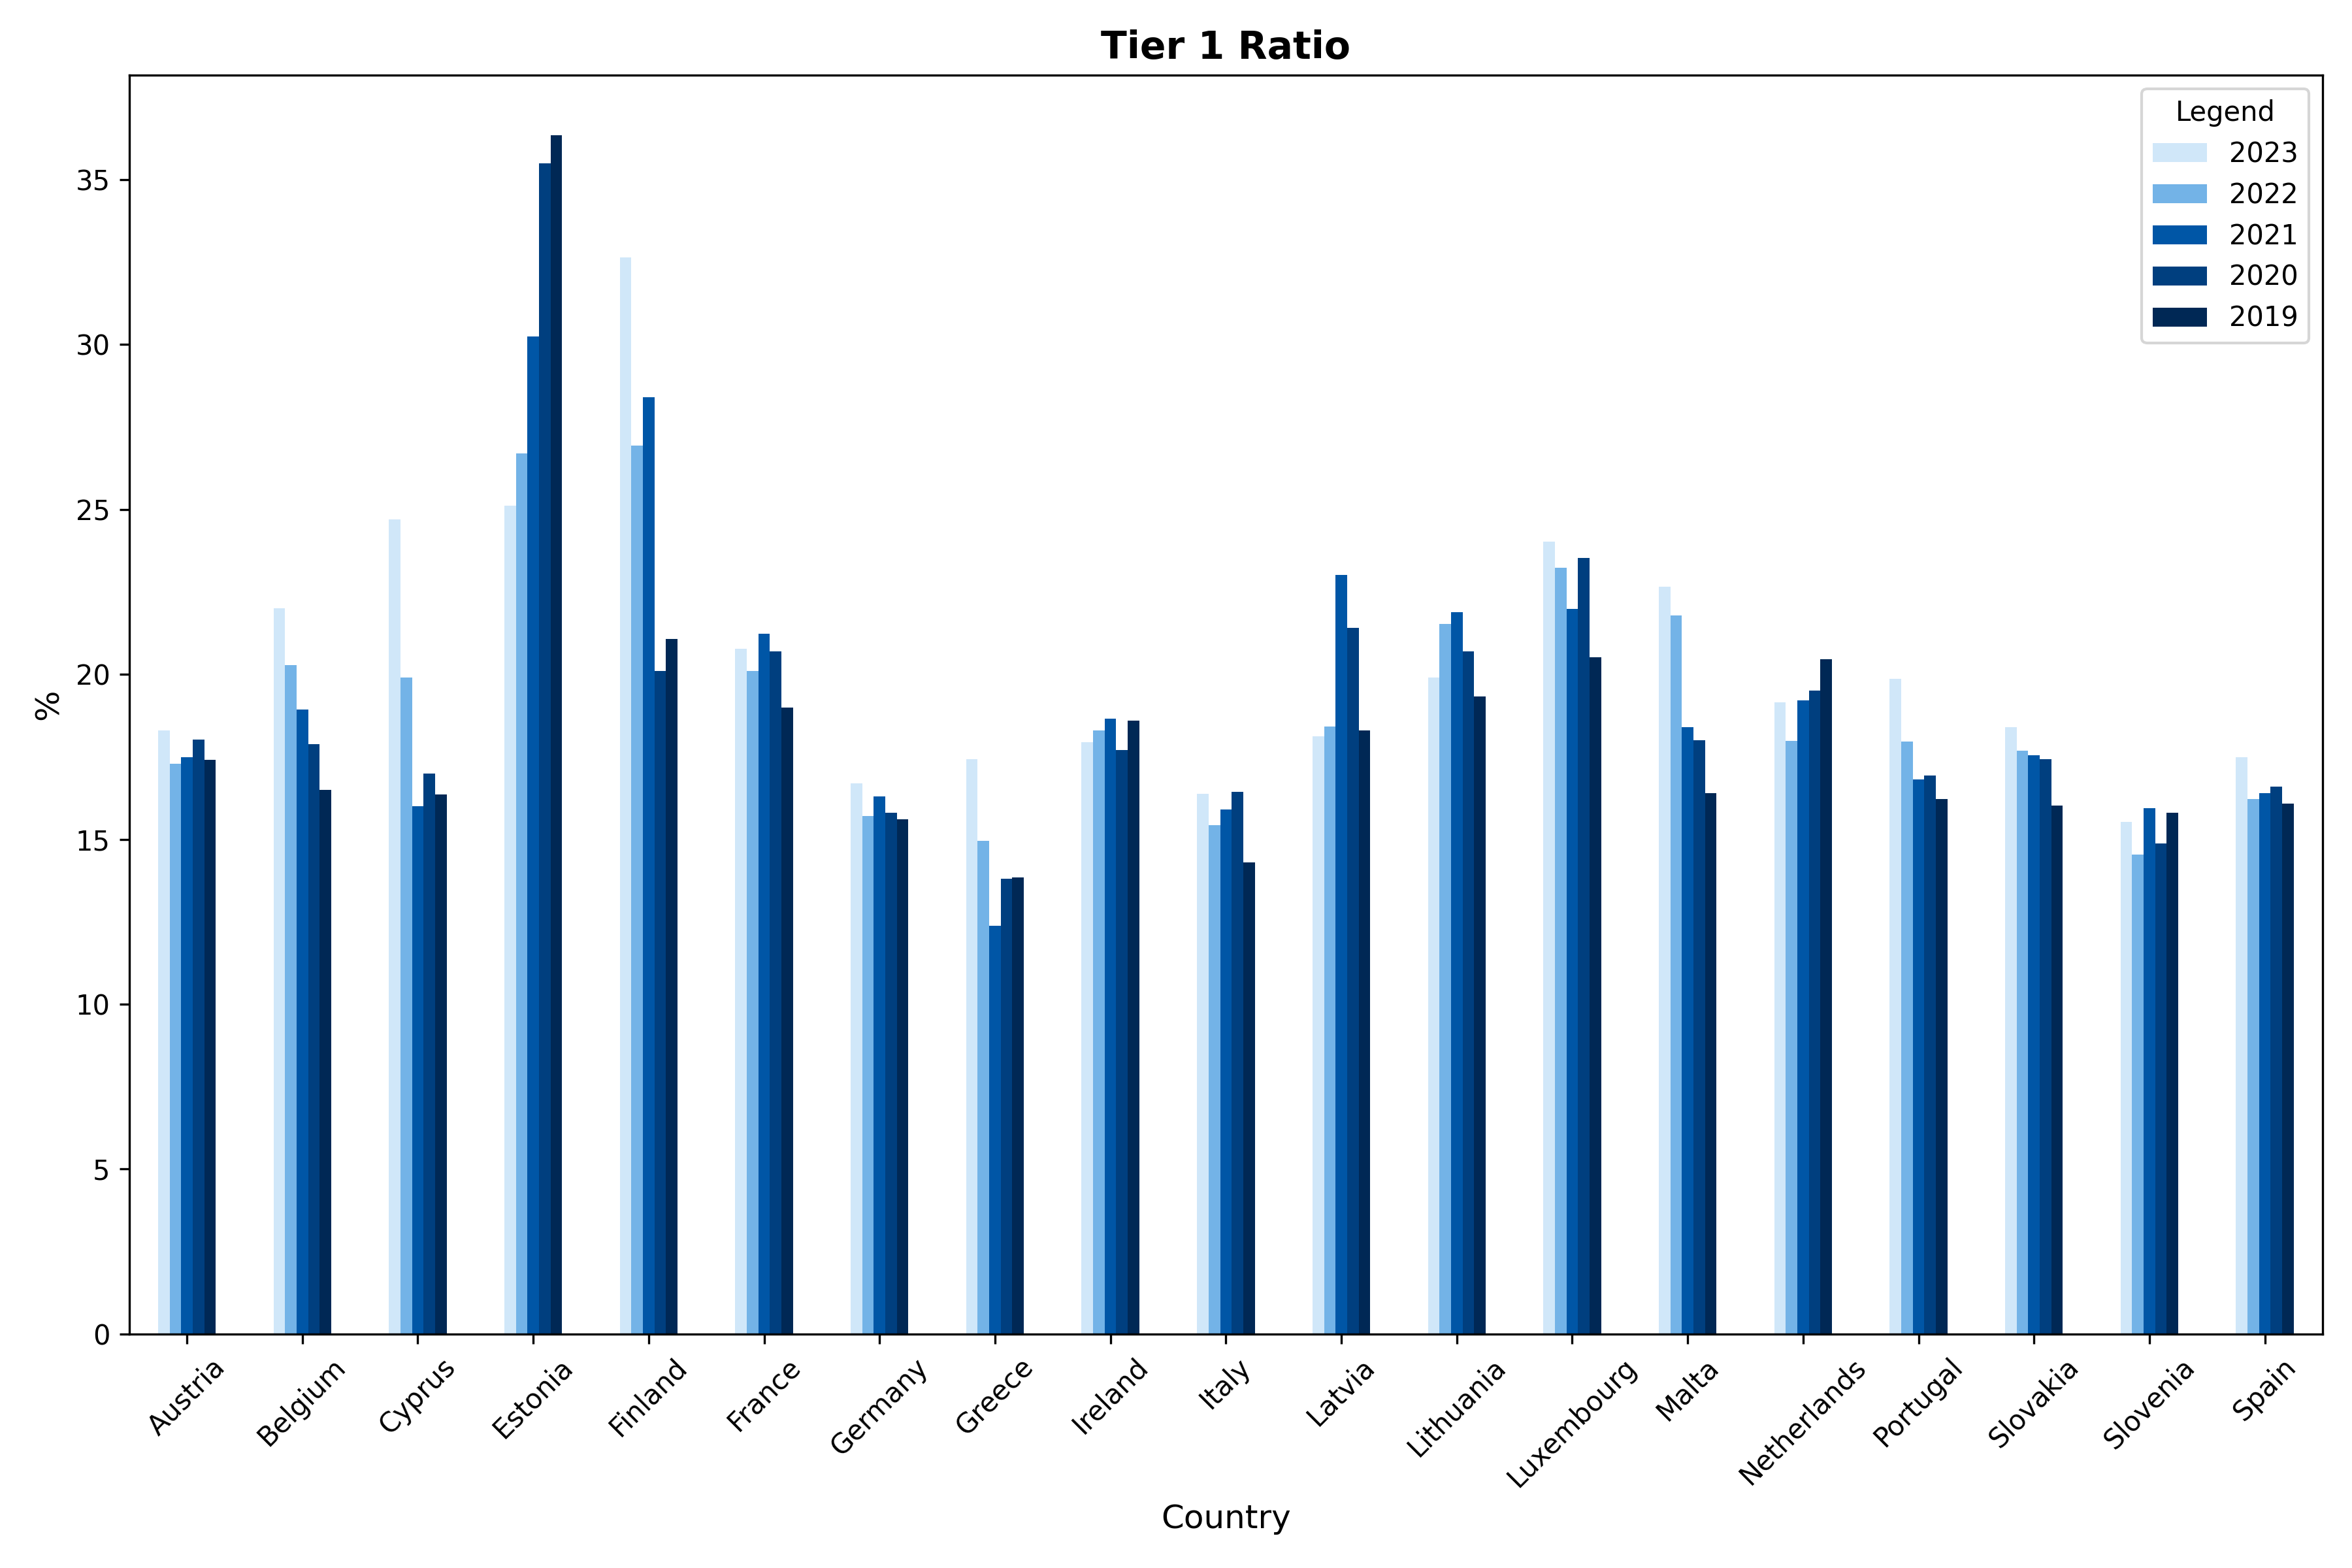

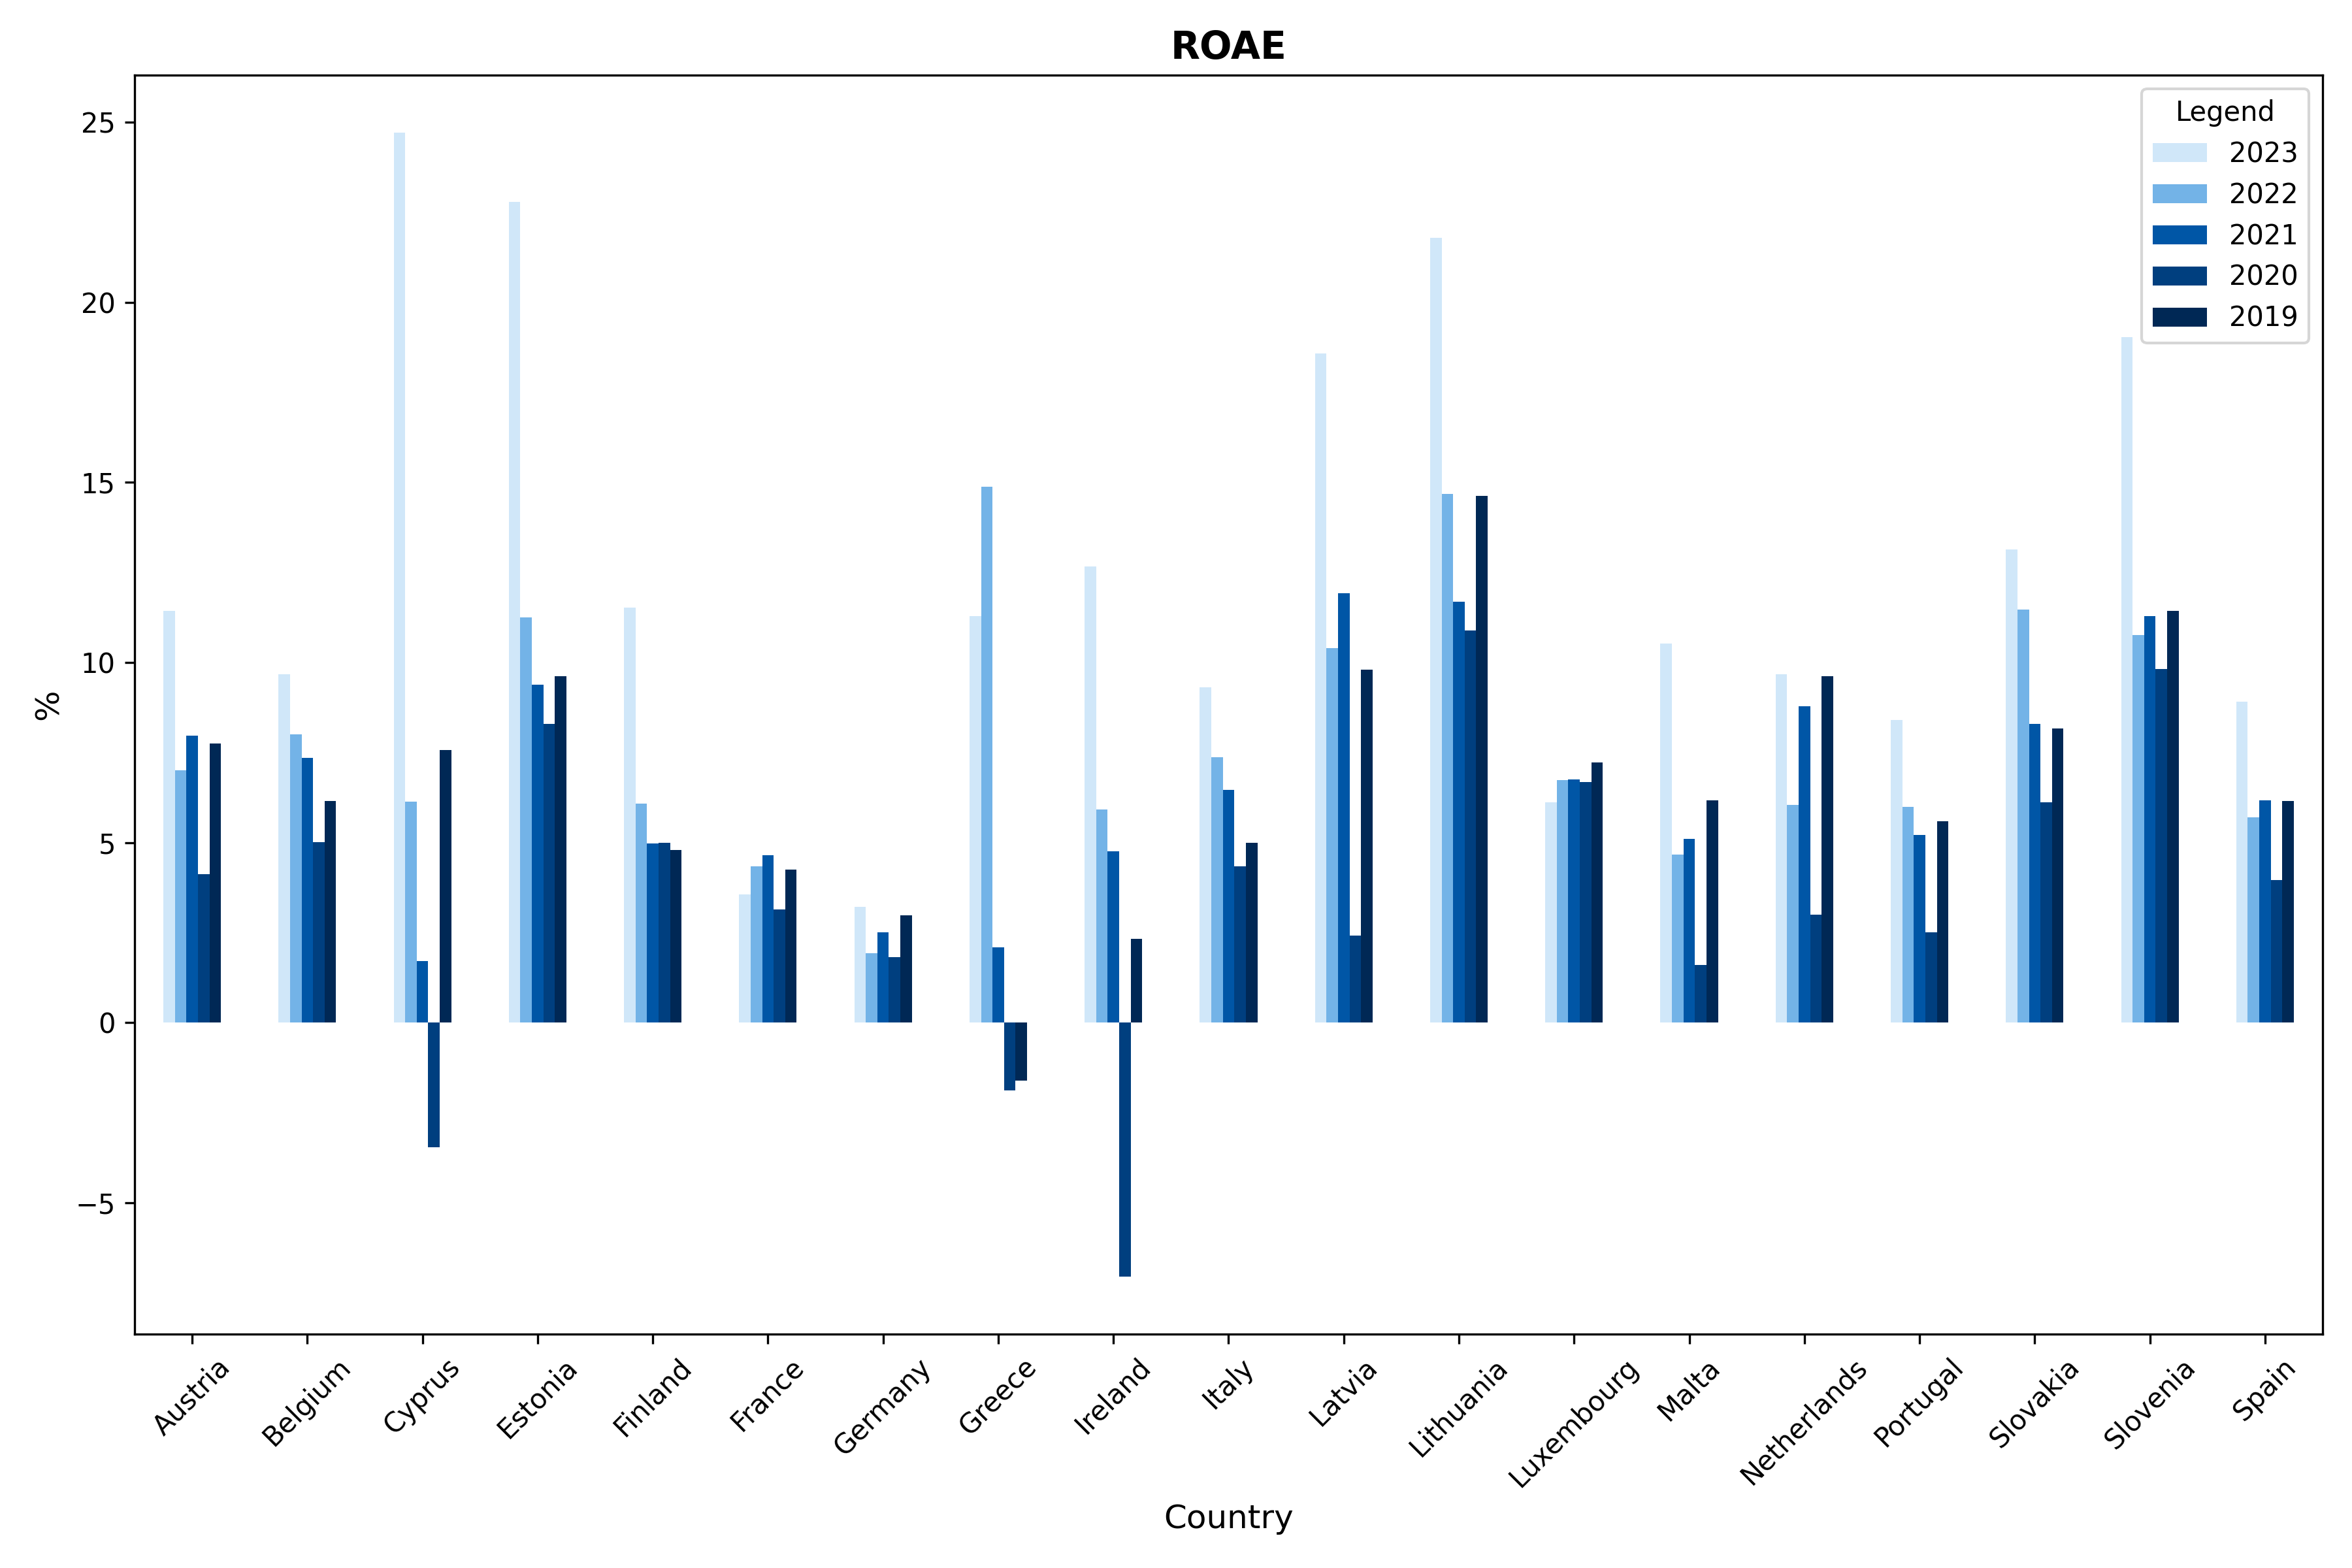

In [7]:
# Display the three key charts inline
for fname in ['impaired_loans_rwas.png', 'tier_1_ratio.png', 'roae.png']:
    display(Image(filename=f'../outputs/figures/{fname}'))

## 5. Key findings

Verified directly from `output_clean.xlsx` (cross-country medians for ratio indicators). No statistical significance testing has been performed -- these are descriptive observations.

In [8]:
xl = pd.ExcelFile('../data/output_clean.xlsx')

print("Asset quality (Impaired loans/RWA) - Cyprus & Greece convergence:")
df = xl.parse('Impaired loans-RWAs')
display(df[df['Country ISO code'].isin(['CY', 'GR'])][['Country ISO code', '2019', '2020', '2021', '2022', '2023']])
print("Cross-country median:", df[['2019', '2023']].median().to_dict())

Asset quality (Impaired loans/RWA) - Cyprus & Greece convergence:


,Country ISO code,2019,2020,2021,2022,2023
2,CY,43.096770,27.521180,9.991739,9.888156,9.280254
8,GR,39.338434,29.928306,10.454057,9.652093,2.111829


Cross-country median: {'2019': 4.12552, '2023': 3.40757}


In [9]:
print("Capitalisation - cross-country median by year:")
print("Tier 1 Ratio:            ", xl.parse('Tier 1 Ratio')[['2019','2020','2021','2022','2023']].median().to_dict())
print("Tot. cap. adequacy ratio:", xl.parse('Tot. cap. adequacy ratio')[['2019','2020','2021','2022','2023']].median().to_dict())

Capitalisation - cross-country median by year:
Tier 1 Ratio:             {'2019': 16.505, '2020': 17.885, '2021': 18.4, '2022': 18.3, '2023': 19.15}
Tot. cap. adequacy ratio: {'2019': 19.0, '2020': 19.6, '2021': 19.75, '2022': 19.85, '2023': 20.85}


In [10]:
print("Profitability - cross-country median by year:")
print("ROAE:", xl.parse('ROAE')[['2019','2020','2021','2022','2023']].median().to_dict())
print("ROAA:", xl.parse('ROAA')[['2019','2020','2021','2022','2023']].median().to_dict())

Profitability - cross-country median by year:
ROAE: {'2019': 6.174949111036, '2020': 3.9571155194185, '2021': 6.457275057699, '2022': 6.732938696729001, '2023': 11.281756853739}
ROAA: {'2019': 0.5483187377000001, '2020': 0.3093148287125, '2021': 0.541425333669, '2022': 0.560863127825, '2023': 1.0384663489705}


## 6. Conclusions

- **Asset quality** converged sharply: Cyprus (43.1% -> 9.3%) and Greece (39.3% -> 2.1%) closed most of their gap with the rest of the sample, while the cross-country median stayed low and stable (4.1% -> 3.4%). Note: individual bank-level outlier detection does NOT flag this pattern (only 18 and 17 flagged bank-years for CY/GR respectively), because the elevated level was shared across most banks in those countries, not driven by one deviant bank -- the pattern only shows up at the aggregated, country-level view.
- **Capitalisation** increased overall, though not monotonically: median Tier 1 Ratio 16.5% (2019) -> 17.9% -> 18.4% -> 18.3% (2022, a small dip) -> 19.2% (2023); median Total Capital Adequacy Ratio 19.0% -> 20.9%. No statistical test for a break or trend has been run.
- **Profitability** dipped in 2020 (median ROAE 6.2% -> 4.0%, ROAA 0.55% -> 0.31%), consistent with pandemic provisioning, then recovered and rose sharply by 2023 (ROAE 11.3%, ROAA 1.04%).

**Limitations (full discussion in `../README.md` and `../data/README.md`):**
- Ratio indicators describe the representative bank in the sample, not a weighted system-wide average.
- Bank coverage ranges from 2 (Estonia) to 106 (France) banks in a single year -- treat small-country medians with more caution.
- Summed totals partly reflect a changing set of reporting banks year to year -- see the balanced-panel comparison above; it narrows but does not eliminate this concern.
- Missing data (up to 38%) and flagged-but-not-removed outliers further limit how far these patterns should be pushed.
- "Impaired loans-RWAs" is impaired loans over risk-weighted assets, not the standard NPL ratio.
- The `src/` scripts are directory-independent; this notebook itself assumes it's run from `notebooks/` (the Jupyter default).

This is a descriptive cross-country comparison, not a causal analysis. For the relationship between ECB monetary policy and bank indicators via panel regression, see the companion project `monetary-policy-banking-analysis`.